In [1]:
# ============================================================
# Step 1: Mount Drive and set base project path
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

base = "/content/drive/MyDrive/Quantum_DL_MNIST"

Mounted at /content/drive


In [2]:
# ============================================================
# Step 2: Import libraries we'll need for this notebook
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import json
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

print("Libraries loaded")
print("PyTorch version:", torch.__version__)

Libraries loaded
PyTorch version: 2.11.0+cpu


In [3]:
# ============================================================
# Step 3: Load the saved splits and normalization stats from
# Chunk 1 (do NOT recompute anything — reuse exactly what we saved)
# ============================================================

train_idx = np.load(f"{base}/splits/train_indices.npy")
val_idx   = np.load(f"{base}/splits/val_indices.npy")
test_idx  = np.load(f"{base}/splits/test_indices.npy")

with open(f"{base}/splits/normalization_stats.json") as f:
    norm_stats = json.load(f)

mean = norm_stats["mean"]
std  = norm_stats["std"]

print("Train indices:", len(train_idx))
print("Val indices:", len(val_idx))
print("Test indices:", len(test_idx))
print("Mean:", mean, "| Std:", std)

Train indices: 10132
Val indices: 2533
Test indices: 2115
Mean: 0.12149777263402939 | Std: 0.30103927850723267


In [4]:
# ============================================================
# Step 4: Re-download MNIST (already cached in Drive, so this
# will be fast) — kept as train_full and test_full, never pooled
# ============================================================

train_full = torchvision.datasets.MNIST(
    root=f"{base}/data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_full = torchvision.datasets.MNIST(
    root=f"{base}/data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

print("Train full:", len(train_full))
print("Test full:", len(test_full))

Train full: 60000
Test full: 10000


In [5]:
# ============================================================
# Step 5: Recreate the BinaryMNIST dataset class
# (same definition as Chunk 1 — applies normalization per sample)
# ============================================================

class BinaryMNIST(Dataset):
    def __init__(self, full_dataset, indices, mean, std):
        self.full_dataset = full_dataset
        self.indices = indices
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_idx = self.indices[i]
        image, label = self.full_dataset[real_idx]
        image = (image - self.mean) / self.std
        label = torch.tensor(float(label))
        return image, label

print("BinaryMNIST class ready")

BinaryMNIST class ready


In [6]:
# ============================================================
# Step 6: Build datasets and DataLoaders using the saved indices
# ============================================================

train_dataset = BinaryMNIST(train_full, train_idx, mean, std)
val_dataset   = BinaryMNIST(train_full, val_idx, mean, std)
test_dataset  = BinaryMNIST(test_full, test_idx, mean, std)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 317
Val batches: 80
Test batches: 67


In [7]:
# ============================================================
# Step 7: Compute the majority-class baseline
# Predicts whichever class is more common in training data,
# then checks how well that trivial guess does on the test set
# ============================================================

# Which class is more common in training?
train_labels_for_majority = train_full.targets[train_idx].numpy()
majority_class = 1 if (train_labels_for_majority == 1).sum() > (train_labels_for_majority == 0).sum() else 0

print("Majority class in training data:", majority_class)

# Get true labels for the test set
test_labels = test_full.targets[test_idx].numpy()

# "Predict" the majority class for every single test sample
majority_predictions = np.full_like(test_labels, fill_value=majority_class)

# Accuracy = how often the trivial guess matches the true label
majority_accuracy = (majority_predictions == test_labels).mean()

print(f"Majority baseline accuracy on test set: {majority_accuracy*100:.2f}%")

Majority class in training data: 1
Majority baseline accuracy on test set: 53.66%


In [8]:
# ============================================================
# Step 8: Save the majority baseline result so we can pull it
# into our final comparison table later (Chunk 9)
# ============================================================

import os

os.makedirs(f"{base}/results/Majority_Baseline", exist_ok=True)

baseline_result = {
    "model": "Majority Baseline",
    "majority_class": int(majority_class),
    "test_accuracy": float(majority_accuracy)
}

with open(f"{base}/results/Majority_Baseline/results.json", "w") as f:
    json.dump(baseline_result, f, indent=2)

print("Saved:", baseline_result)

Saved: {'model': 'Majority Baseline', 'majority_class': 1, 'test_accuracy': 0.5366430260047281}


In [9]:
# ============================================================
# Step 9: Set up reproducibility (seeding) before we build
# and train any real model — this ties every run to a fixed seed
# ============================================================

import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    torch.set_num_threads(4)

SEEDS = [42, 123, 2024, 7, 99]

# For now, just test with the first seed
set_seed(SEEDS[0])
print("Seed set to:", SEEDS[0])

Seed set to: 42


In [10]:
# ============================================================
# Step 10: Define the NN model architecture
# 784 -> 128 -> 64 -> 1 (raw logit, no sigmoid applied here)
# He initialization used for all Linear layers
# ============================================================

class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 1)

        # He initialization (appropriate for ReLU-activated layers)
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc3.weight, nonlinearity='relu')

    def forward(self, x):
        x = self.flatten(x)      # (batch, 1, 28, 28) -> (batch, 784)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)          # raw logit, no activation
        return x

model = NN()
print(model)

NN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)


In [11]:
# ============================================================
# Step 11: Count trainable parameters (needed for our
# computational comparison table later, Section 21)
# ============================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

n_params = count_parameters(model)
print("Total trainable parameters in NN:", n_params)

Total trainable parameters in NN: 108801


In [12]:
# ============================================================
# Step 12: Quick sanity check — run one batch through the
# untrained model to confirm shapes work end-to-end
# ============================================================

sample_images, sample_labels = next(iter(train_loader))
print("Input batch shape:", sample_images.shape)

output = model(sample_images)
print("Output shape:", output.shape)
print("Sample raw logits:", output[:5].detach().numpy().flatten())

Input batch shape: torch.Size([32, 1, 28, 28])
Output shape: torch.Size([32, 1])
Sample raw logits: [-0.5782664  -1.7654297  -1.4671587  -0.01387769  0.44487134]


In [13]:
# ============================================================
# Step 13: Define loss function and optimizer
# BCEWithLogitsLoss works directly on raw logits (no sigmoid needed)
# Adam optimizer with fixed learning rate 1e-3
# ============================================================

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [14]:
# ============================================================
# Step 14: Write helper functions to run one training epoch
# and one evaluation epoch (reused for train + validation)
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        labels = labels.unsqueeze(1)  # shape (batch,) -> (batch,1) to match output

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            labels = labels.unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total

print("Training and evaluation functions ready")

Training and evaluation functions ready


In [15]:
# ============================================================
# Step 15: Quick test — run ONE epoch to confirm training works
# before we build the full training loop with early stopping
# ============================================================

train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
val_loss, val_acc = evaluate(model, val_loader, criterion)

print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
print(f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")

Train loss: 0.0098 | Train acc: 0.9964
Val loss: 0.0021 | Val acc: 0.9992


In [16]:
# ============================================================
# Step 16: Full training loop with early stopping
# patience=5, max 30 epochs, restores best weights (Section 13)
# ============================================================

import copy
import time

def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer,
                                max_epochs=30, patience=5):
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    epochs_no_improve = 0

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:2d} | Train loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| Val loss {val_loss:.4f} acc {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    training_time = time.time() - start_time

    # Restore best weights
    model.load_state_dict(best_model_state)

    return model, history, best_epoch, epoch, training_time

print("Full training function ready")

Full training function ready


In [17]:
# ============================================================
# Step 17: Quick single-seed test run of the full training loop
# (just to confirm early stopping works before looping all 5 seeds)
# ============================================================

set_seed(42)
model = NN()  # fresh model
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

trained_model, history, best_epoch, total_epochs, training_time = train_with_early_stopping(
    model, train_loader, val_loader, criterion, optimizer
)

print(f"\nBest epoch: {best_epoch} | Total epochs run: {total_epochs}")
print(f"Training time: {training_time:.2f} seconds")

Epoch  1 | Train loss 0.0109 acc 0.9962 | Val loss 0.0043 acc 0.9988
Epoch  2 | Train loss 0.0033 acc 0.9989 | Val loss 0.0035 acc 0.9992
Epoch  3 | Train loss 0.0020 acc 0.9992 | Val loss 0.0036 acc 0.9984
Epoch  4 | Train loss 0.0004 acc 0.9999 | Val loss 0.0028 acc 0.9992
Epoch  5 | Train loss 0.0029 acc 0.9990 | Val loss 0.0025 acc 0.9992
Epoch  6 | Train loss 0.0003 acc 0.9998 | Val loss 0.0047 acc 0.9992
Epoch  7 | Train loss 0.0009 acc 0.9999 | Val loss 0.0061 acc 0.9984
Epoch  8 | Train loss 0.0001 acc 1.0000 | Val loss 0.0080 acc 0.9984
Epoch  9 | Train loss 0.0000 acc 1.0000 | Val loss 0.0061 acc 0.9988
Epoch 10 | Train loss 0.0000 acc 1.0000 | Val loss 0.0071 acc 0.9984
Early stopping triggered at epoch 10

Best epoch: 5 | Total epochs run: 10
Training time: 51.73 seconds


In [18]:
# ============================================================
# Step 18: Helper function to get test-set predictions
# (probabilities, not just hard labels — needed for ROC/PR later)
# ============================================================

def get_test_predictions(model, loader):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            probs = torch.sigmoid(outputs).squeeze(1)
            all_probs.extend(probs.numpy().tolist())
            all_labels.extend(labels.numpy().tolist())
    return np.array(all_probs), np.array(all_labels)

print("Prediction helper ready")

Prediction helper ready


In [19]:
# ============================================================
# Step 19: Run the full 5-seed official training loop for NN
# Saves: history, best model weights, test predictions, metadata
# for EACH of the 5 seeds, into results/NN/
# ============================================================

results_dir = f"{base}/results/NN"
models_dir = f"{base}/models/NN"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

all_runs_summary = []

for run_num, seed in enumerate(SEEDS, start=1):
    print(f"\n{'='*60}")
    print(f"RUN {run_num}/5 | Seed = {seed}")
    print(f"{'='*60}")

    set_seed(seed)
    model = NN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    trained_model, history, best_epoch, total_epochs, training_time = train_with_early_stopping(
        model, train_loader, val_loader, criterion, optimizer
    )

    # Test set predictions (probabilities, not just hard labels)
    test_probs, test_labels_arr = get_test_predictions(trained_model, test_loader)

    # Save model weights
    torch.save(trained_model.state_dict(), f"{models_dir}/run{run_num}_seed{seed}.pt")

    # Save predictions
    np.savez(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz",
             probs=test_probs, labels=test_labels_arr)

    # Save per-run metadata
    run_summary = {
        "run": run_num,
        "seed": seed,
        "best_epoch": best_epoch,
        "total_epochs_run": total_epochs,
        "training_time_sec": training_time,
        "n_params": count_parameters(trained_model),
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
    }
    all_runs_summary.append(run_summary)

    with open(f"{results_dir}/run{run_num}_seed{seed}_history.json", "w") as f:
        json.dump(history, f, indent=2)

# Save summary of all 5 runs
with open(f"{results_dir}/all_runs_summary.json", "w") as f:
    json.dump(all_runs_summary, f, indent=2)

print("\n\nAll 5 runs complete. Summary:")
for r in all_runs_summary:
    print(r)


RUN 1/5 | Seed = 42
Epoch  1 | Train loss 0.0109 acc 0.9962 | Val loss 0.0043 acc 0.9988
Epoch  2 | Train loss 0.0033 acc 0.9989 | Val loss 0.0035 acc 0.9992
Epoch  3 | Train loss 0.0020 acc 0.9992 | Val loss 0.0036 acc 0.9984
Epoch  4 | Train loss 0.0004 acc 0.9999 | Val loss 0.0028 acc 0.9992
Epoch  5 | Train loss 0.0029 acc 0.9990 | Val loss 0.0025 acc 0.9992
Epoch  6 | Train loss 0.0003 acc 0.9998 | Val loss 0.0047 acc 0.9992
Epoch  7 | Train loss 0.0009 acc 0.9999 | Val loss 0.0061 acc 0.9984
Epoch  8 | Train loss 0.0001 acc 1.0000 | Val loss 0.0080 acc 0.9984
Epoch  9 | Train loss 0.0000 acc 1.0000 | Val loss 0.0061 acc 0.9988
Epoch 10 | Train loss 0.0000 acc 1.0000 | Val loss 0.0071 acc 0.9984
Early stopping triggered at epoch 10

RUN 2/5 | Seed = 123
Epoch  1 | Train loss 0.0131 acc 0.9950 | Val loss 0.0028 acc 0.9992
Epoch  2 | Train loss 0.0021 acc 0.9994 | Val loss 0.0053 acc 0.9980
Epoch  3 | Train loss 0.0055 acc 0.9984 | Val loss 0.0026 acc 0.9992
Epoch  4 | Train loss 0

In [20]:
# ============================================================
# Step 20: Compute full metrics for each of the 5 runs
# Accuracy, Precision, Recall, Specificity, F1, Balanced Acc,
# MCC, ROC-AUC, PR-AUC (Section 18)
# ============================================================

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, balanced_accuracy_score, matthews_corrcoef,
                               roc_auc_score, average_precision_score, confusion_matrix)

def compute_metrics(probs, labels, threshold=0.5):
    preds = (probs > threshold).astype(int)
    labels = labels.astype(int)

    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    specificity = tn / (tn + fp)  # negative class = digit 0

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),         # positive class = digit 1
        "specificity": specificity,
        "f1": f1_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "mcc": matthews_corrcoef(labels, preds),
        "roc_auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}
    }
    return metrics

# Compute metrics for each run
all_metrics = []
for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    m = compute_metrics(probs, labels)
    m["run"] = run_num
    m["seed"] = seed
    all_metrics.append(m)
    print(f"Run {run_num} (seed {seed}): Acc={m['accuracy']:.4f} F1={m['f1']:.4f} "
          f"ROC-AUC={m['roc_auc']:.4f}")

Run 1 (seed 42): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000
Run 2 (seed 123): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000
Run 3 (seed 2024): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000
Run 4 (seed 7): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000
Run 5 (seed 99): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000


In [21]:
# ============================================================
# Step 21: Summarize as Mean +/- SD across the 5 runs
# ============================================================

import pandas as pd

metric_names = ["accuracy", "precision", "recall", "specificity", "f1",
                 "balanced_accuracy", "mcc", "roc_auc", "pr_auc"]

df_metrics = pd.DataFrame(all_metrics)[["run", "seed"] + metric_names]
print("Per-run metrics:")
print(df_metrics)

print("\nMean +/- SD across 5 runs:")
summary = df_metrics[metric_names].agg(['mean', 'std'])
print(summary)

Per-run metrics:
   run  seed  accuracy  precision  recall  specificity       f1  \
0    1    42  0.999527    0.99912     1.0      0.99898  0.99956   
1    2   123  0.999527    0.99912     1.0      0.99898  0.99956   
2    3  2024  0.999527    0.99912     1.0      0.99898  0.99956   
3    4     7  0.999527    0.99912     1.0      0.99898  0.99956   
4    5    99  0.999527    0.99912     1.0      0.99898  0.99956   

   balanced_accuracy      mcc   roc_auc    pr_auc  
0            0.99949  0.99905  1.000000  1.000000  
1            0.99949  0.99905  1.000000  1.000000  
2            0.99949  0.99905  1.000000  1.000000  
3            0.99949  0.99905  1.000000  1.000000  
4            0.99949  0.99905  0.999999  0.999999  

Mean +/- SD across 5 runs:
          accuracy     precision  recall   specificity       f1  \
mean  9.995272e-01  9.991197e-01     1.0  9.989796e-01  0.99956   
std   1.241267e-16  1.241267e-16     0.0  1.241267e-16  0.00000   

      balanced_accuracy           mcc 

In [22]:
# ============================================================
# Step 22: Save the final metrics table for NN
# (this feeds directly into Chunk 9's cross-model comparison)
# ============================================================

df_metrics.to_csv(f"{results_dir}/NN_metrics_per_run.csv", index=False)
summary.to_csv(f"{results_dir}/NN_metrics_summary.csv")

print("Saved NN_metrics_per_run.csv and NN_metrics_summary.csv to:")
print(results_dir)
print("\n--- CHUNK 2 (NN model) COMPLETE ---")

Saved NN_metrics_per_run.csv and NN_metrics_summary.csv to:
/content/drive/MyDrive/Quantum_DL_MNIST/results/NN

--- CHUNK 2 (NN model) COMPLETE ---


In [23]:
# ============================================================
# Step 23: Documentation sketch for NN notebook (Chunk 2)
# Not final write-up — just structured notes to expand later
# ============================================================

nn_documentation_sketch = {

    "model_name": "Model 1 - Fully Connected Neural Network (NN)",

    "purpose": "Baseline demonstrating performance without spatial convolution. "
               "Answers Ablation Question A: does a neural network beat the trivial majority baseline?",

    "architecture": "784 -> Linear(784,128) -> ReLU -> Linear(128,64) -> ReLU -> Linear(64,1) -> raw logit",

    "design_choices": [
        "No dropout used - keeps regularization symmetric across NN and CNN (only early stopping regularizes)",
        "He initialization used for all Linear layers (appropriate for ReLU activations)",
        "BCEWithLogitsLoss used on raw logit (numerically stable, same loss used by all 4 models)",
        "NN is NOT parameter-matched to other models - it's a standalone baseline, not part of the core ablation chain"
    ],

    "dataset_recap": {
        "classes": "digits 0 and 1 only",
        "positive_class": 1,
        "negative_class": 0,
        "train_size": 10132,
        "val_size": 2533,
        "test_size": 2115,
        "official_train_test_kept_separate": True,
        "class_balance_train": "46.77% zeros, 53.23% ones",
        "normalization_mean": 0.12149777263402939,
        "normalization_std": 0.30103927850723267
    },

    "majority_baseline_result": {
        "majority_class": 1,
        "test_accuracy": 0.5366430260047281,
        "note": "Performance floor every trained model must clear"
    },

    "training_protocol": {
        "optimizer": "Adam",
        "learning_rate": "1e-3, fixed",
        "loss": "BCEWithLogitsLoss",
        "max_epochs": 30,
        "early_stopping_patience": 5,
        "batch_size": 32,
        "seeds": [42, 123, 2024, 7, 99],
        "num_workers": 0
    },

    "results_summary": {
        "n_params": 108801,
        "test_accuracy_mean": 0.999527,
        "test_accuracy_std": "~0 (essentially zero variance across seeds)",
        "roc_auc_mean": 0.9999998,
        "f1_mean": 0.99956,
        "note_on_variance": "Near-zero std across all 5 seeds - task is visually easy for this "
                             "model, converges to nearly identical solution regardless of seed. "
                             "Worth flagging honestly in write-up; may contrast with CNN+Classical "
                             "vs CNN+Quantum variance later."
    },

    "best_epoch_range_across_runs": "1 to 5 (varies by seed, as expected - Section 17)",
    "total_epochs_range_across_runs": "6 to 10",
    "training_time_range_sec": "29 to 49 seconds per run",

    "files_saved": [
        "results/NN/run{1-5}_seed{seed}_predictions.npz",
        "results/NN/run{1-5}_seed{seed}_history.json",
        "results/NN/all_runs_summary.json",
        "results/NN/NN_metrics_per_run.csv",
        "results/NN/NN_metrics_summary.csv",
        "models/NN/run{1-5}_seed{seed}.pt",
        "results/Majority_Baseline/results.json"
    ],

    "open_questions_for_final_writeup": [
        "Should we note in Limitations that binary 0/1 MNIST is 'too easy', explaining near-ceiling performance for all models?",
        "Confirm whether near-zero NN variance is worth a dedicated sentence in Discussion",
        "Decide how to visually present a near-1.0 ROC-AUC curve without it looking like a rendering error"
    ]
}

# Save to documentation folder
os.makedirs(f"{base}/documentation", exist_ok=True)
with open(f"{base}/documentation/01_NN_documentation_sketch.json", "w") as f:
    json.dump(nn_documentation_sketch, f, indent=2)

print("Saved documentation sketch to documentation/01_NN_documentation_sketch.json")

Saved documentation sketch to documentation/01_NN_documentation_sketch.json


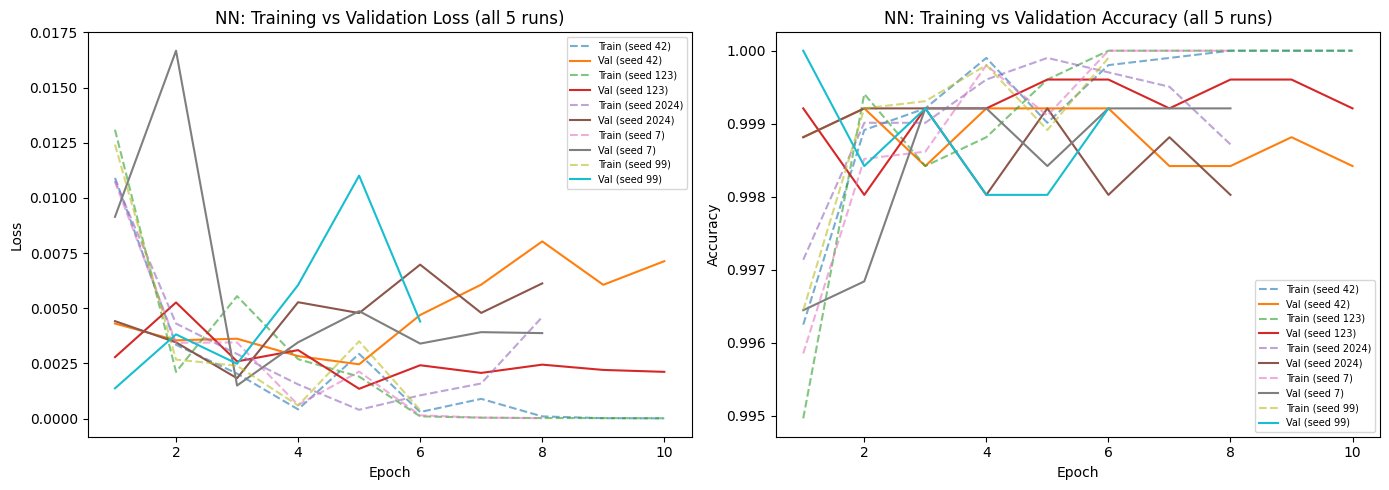

Saved: figures/Fig1-2_NN_loss_accuracy_curves.png


In [24]:
# ============================================================
# Step 23: Plot train/val loss and accuracy curves
# One figure per run (5 runs) - Section 23, Fig 1-2 for NN
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for run_num, seed in enumerate(SEEDS, start=1):
    with open(f"{results_dir}/run{run_num}_seed{seed}_history.json") as f:
        history = json.load(f)

    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], linestyle='--', alpha=0.6, label=f"Train (seed {seed})")
    axes[0].plot(epochs, history["val_loss"], linestyle='-', label=f"Val (seed {seed})")

    axes[1].plot(epochs, history["train_acc"], linestyle='--', alpha=0.6, label=f"Train (seed {seed})")
    axes[1].plot(epochs, history["val_acc"], linestyle='-', label=f"Val (seed {seed})")

axes[0].set_title("NN: Training vs Validation Loss (all 5 runs)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=7)

axes[1].set_title("NN: Training vs Validation Accuracy (all 5 runs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig1-2_NN_loss_accuracy_curves.png", dpi=150)
plt.show()

print("Saved: figures/Fig1-2_NN_loss_accuracy_curves.png")

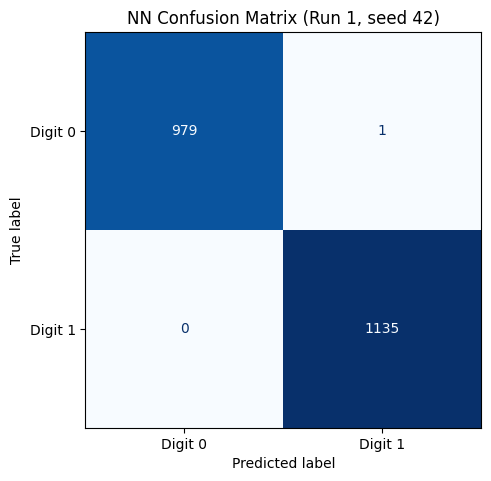

Saved: figures/Fig9_NN_confusion_matrix.png


In [25]:
# ============================================================
# Step 24: Plot the confusion matrix for a representative run
# (Section 19 - one per model; using Run 1 / seed 42 as representative)
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

data = np.load(f"{results_dir}/run1_seed42_predictions.npz")
probs, labels = data["probs"], data["labels"]
preds = (probs > 0.5).astype(int)

cm = confusion_matrix(labels.astype(int), preds)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Digit 0", "Digit 1"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("NN Confusion Matrix (Run 1, seed 42)")

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig9_NN_confusion_matrix.png", dpi=150)
plt.show()

print("Saved: figures/Fig9_NN_confusion_matrix.png")

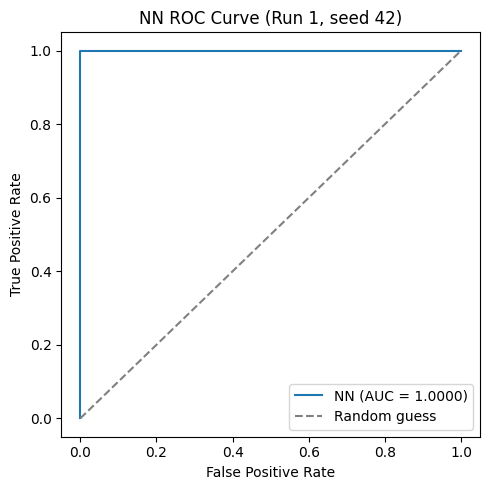

Saved: figures/NN_roc_curve.png and NN_roc_curve_data.npz


In [26]:
# ============================================================
# Step 25: Plot ROC curve (Section 23, Fig 13 - combined later,
# but save NN's individual curve data now for that combined plot)
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(labels, probs)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f"NN (AUC = {roc_auc_score(labels, probs):.4f})")
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("NN ROC Curve (Run 1, seed 42)")
ax.legend()

plt.tight_layout()
plt.savefig(f"{base}/figures/NN_roc_curve.png", dpi=150)
plt.show()

# Save raw ROC data so Chunk 9 can build the combined Fig 13 (all 4 models on one plot)
np.savez(f"{results_dir}/NN_roc_curve_data.npz", fpr=fpr, tpr=tpr)
print("Saved: figures/NN_roc_curve.png and NN_roc_curve_data.npz")

In [27]:
# ============================================================
# Step 26: Save ALL 5 runs' confusion matrices as supplementary
# data (Section 19 - main figure shows 1 representative run,
# but all raw per-run matrices must be retained)
# ============================================================

all_confusion_matrices = {}

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    preds = (probs > 0.5).astype(int)
    cm = confusion_matrix(labels.astype(int), preds)

    all_confusion_matrices[f"run{run_num}_seed{seed}"] = cm.tolist()
    print(f"Run {run_num} (seed {seed}):")
    print(cm)
    print()

with open(f"{results_dir}/NN_all_confusion_matrices_supplementary.json", "w") as f:
    json.dump(all_confusion_matrices, f, indent=2)

print("Saved: NN_all_confusion_matrices_supplementary.json (all 5 runs)")

Run 1 (seed 42):
[[ 979    1]
 [   0 1135]]

Run 2 (seed 123):
[[ 979    1]
 [   0 1135]]

Run 3 (seed 2024):
[[ 979    1]
 [   0 1135]]

Run 4 (seed 7):
[[ 979    1]
 [   0 1135]]

Run 5 (seed 99):
[[ 979    1]
 [   0 1135]]

Saved: NN_all_confusion_matrices_supplementary.json (all 5 runs)


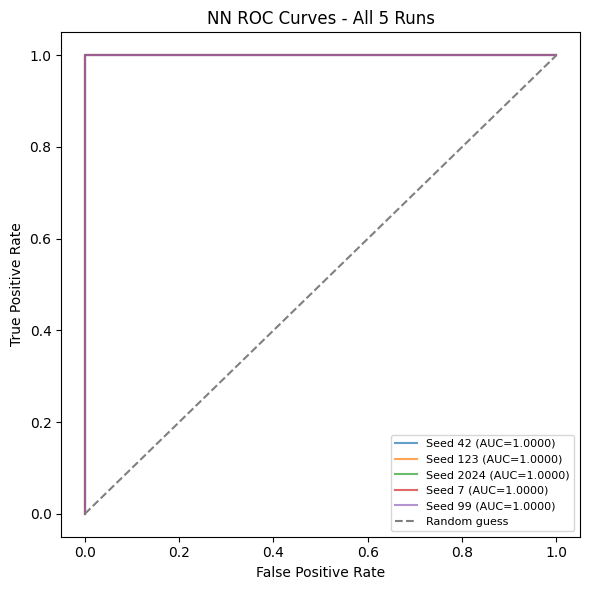

Saved: figures/NN_roc_curves_all_5_runs.png


In [28]:
# ============================================================
# Step 27: Plot ROC curves for ALL 5 runs overlaid (not just one)
# Useful to visually confirm run-to-run consistency
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, alpha=0.7, label=f"Seed {seed} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("NN ROC Curves - All 5 Runs")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{base}/figures/NN_roc_curves_all_5_runs.png", dpi=150)
plt.show()

print("Saved: figures/NN_roc_curves_all_5_runs.png")